In [1]:

# # Ground Truth Testing for SSGAT Model

# This notebook tests the trained GAT models against ground truth data.

# ## Overview
# - Load trained models for each marker
# - Load ground truth data
# - Generate predictions
# - Compare predictions with ground truth
# - Calculate evaluation metrics
# - Visualize results

## Create 5D Ground Truth Data

Create 5-dimensional data with strips parallel to x-axis.


In [6]:
import numpy as np

# Define dimensions
num_channels = 4
intensity_range = (0, 10)
z_range = (1, 24)
y_range = (1, 688)
x_range = (1, 1368)

# Create 5D array initialized with zeros
# Shape: (channel, z, y, x) - intensity is the value stored, not a dimension
# Note: We'll use indices 0-3 for channels 1-4, so channel index = channel - 1
# z, y, x are 1-indexed in description but 0-indexed in array
data = np.zeros((num_channels, z_range[1], y_range[1], x_range[1]), dtype=np.int8)

print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions: (channels={num_channels}, z={z_range[1]}, y={y_range[1]}, x={x_range[1]})")
print(f"Each position stores an intensity value (0-10)")
print(f"Using int8 dtype to minimize file size (1 byte per value)")

# Create strips for channel 1 (index 0)
channel_idx = 0  # Channel 1
strip_width = 50
strip_centers_y = [100, 300, 500]
intensity_min = 5
intensity_max = 10

print(f"\nCreating strips for channel 1:")
print(f"  Strip width: {strip_width}")
print(f"  Strip centers (y): {strip_centers_y}")
print(f"  Intensity range: {intensity_min} to {intensity_max}")

# Create strips parallel to x-axis
for center_y in strip_centers_y:
    # Calculate strip boundaries (convert to 0-indexed)
    y_start = max(0, center_y - strip_width // 2)
    y_end = min(y_range[1], center_y + strip_width // 2)
    
    print(f"\n  Processing strip at y={center_y}:")
    print(f"    y range: {y_start} to {y_end-1}")
    
    # Fill the strip with random integer intensities between 8-10
    # For all z values and all x values in the strip
    for z in range(z_range[1]):
        for y in range(y_start, y_end):
            for x in range(x_range[1]):
                # Generate random integer intensity value between 8-10
                intensity_value = np.random.randint(intensity_min, intensity_max + 1)
                # Store the integer intensity value
                data[channel_idx, z, y, x] = intensity_value

print(f"\n✓ Data creation complete!")
print(f"  Total non-zero values: {np.count_nonzero(data)}")
print(f"  Data range: [{data.min()}, {data.max()}]")
print(f"  Data dtype: {data.dtype}")

# Save the data
np.save('channel1.npy', data)
print(f"\n✓ Data saved to: channel1.npy")


Created 5D data array with shape: (4, 24, 688, 1368)
Dimensions: (channels=4, z=24, y=688, x=1368)
Each position stores an intensity value (0-10)
Using int8 dtype to minimize file size (1 byte per value)

Creating strips for channel 1:
  Strip width: 50
  Strip centers (y): [100, 300, 500]
  Intensity range: 5 to 10

  Processing strip at y=100:
    y range: 75 to 124

  Processing strip at y=300:
    y range: 275 to 324

  Processing strip at y=500:
    y range: 475 to 524

✓ Data creation complete!
  Total non-zero values: 4924800
  Data range: [0, 10]
  Data dtype: int8

✓ Data saved to: channel1.npy


## Add Vertical Strips to Channel 2

Add vertical strips (parallel to Y-axis) to channel 2 and combine with channel 1.


In [11]:
import numpy as np

# Define dimensions (same as channel1)
z_range = (1, 24)
y_range = (1, 688)
x_range = (1, 1368)

z_dim = z_range[1]
y_dim = y_range[1]
x_dim = x_range[1]

# Initialize channel 1 (horizontal strips parallel to x-axis)
channel1 = np.zeros((z_dim, y_dim, x_dim), dtype=np.int8)

# Channel 1 parameters: horizontal strips
strip_width = 50
strip_centers_y = [100, 300, 500]  # Centers along y-axis
intensity_min = 5
intensity_max = 10

print("Creating Channel 1 (horizontal strips parallel to x-axis):")
print(f"  Strip width: {strip_width}")
print(f"  Strip centers (y): {strip_centers_y}")
print(f"  Intensity range: {intensity_min} to {intensity_max}")

# Create horizontal strips for channel 1
for center_y in strip_centers_y:
    y_start = max(0, center_y - strip_width // 2)
    y_end = min(y_dim, center_y + strip_width // 2)
    
    for z in range(z_dim):
        for y in range(y_start, y_end):
            for x in range(x_dim):
                intensity_value = np.random.randint(intensity_min, intensity_max + 1)
                channel1[z, y, x] = intensity_value

print(f"✓ Channel 1 created: {np.count_nonzero(channel1)} non-zero values")

# Initialize channel 2 (vertical strips parallel to y-axis)
channel2 = np.zeros((z_dim, y_dim, x_dim), dtype=np.int8)

# Channel 2 parameters: vertical strips
strip_centers_x = [100, 300, 500, 700, 900, 1100]  # Centers along x-axis

print(f"\nCreating Channel 2 (vertical strips parallel to y-axis):")
print(f"  Strip width: {strip_width}")
print(f"  Strip centers (x): {strip_centers_x}")
print(f"  Intensity range: {intensity_min} to {intensity_max}")

# Create vertical strips for channel 2
for center_x in strip_centers_x:
    x_start = max(0, center_x - strip_width // 2)
    x_end = min(x_dim, center_x + strip_width // 2)
    
    for z in range(z_dim):
        for y in range(y_dim):
            for x in range(x_start, x_end):
                intensity_value = np.random.randint(intensity_min, intensity_max + 1)
                channel2[z, y, x] = intensity_value

print(f"✓ Channel 2 created: {np.count_nonzero(channel2)} non-zero values")

# Combine channels: add values where they overlap
# If both channels have values at (x,y,z), add them together
channel12 = channel1.astype(np.int16) + channel2.astype(np.int16)  # Use int16 to avoid overflow
channel12 = np.clip(channel12, 0, 255).astype(np.int8)  # Clip to int8 range

print(f"\n✓ Channel 12 created by adding Channel 1 + Channel 2")
print(f"  Where both channels have values, they are added together")
print(f"  Example: channel1(100,100,20)=10 + channel2(100,100,20)=6 → channel12(100,100,20)=16")
print(f"  Total non-zero values: {np.count_nonzero(channel12)}")
print(f"  Data range: [{channel12.min()}, {channel12.max()}]")
print(f"  Data shape: {channel12.shape} (z, y, x)")

# Save channel12
np.save('channel12.npy', channel12)
print(f"\n✓ Channel 12 saved to: channel12.npy")
print(f"  Shape: (z={z_dim}, y={y_dim}, x={x_dim})")


Creating Channel 1 (horizontal strips parallel to x-axis):
  Strip width: 50
  Strip centers (y): [100, 300, 500]
  Intensity range: 5 to 10
✓ Channel 1 created: 4924800 non-zero values

Creating Channel 2 (vertical strips parallel to y-axis):
  Strip width: 50
  Strip centers (x): [100, 300, 500, 700, 900, 1100]
  Intensity range: 5 to 10
✓ Channel 2 created: 4953600 non-zero values

✓ Channel 12 created by adding Channel 1 + Channel 2
  Where both channels have values, they are added together
  Example: channel1(100,100,20)=10 + channel2(100,100,20)=6 → channel12(100,100,20)=16
  Total non-zero values: 8798400
  Data range: [0, 20]
  Data shape: (24, 688, 1368) (z, y, x)

✓ Channel 12 saved to: channel12.npy
  Shape: (z=24, y=688, x=1368)


## Visualize Heatmap

Create a heatmap visualization of the data.


Loaded data shape: (4, 24, 688, 1368)
Heatmap shape: (688, 1368)
Heatmap value range: [0, 214]

✓ Heatmap saved to: channel1_heatmap.png


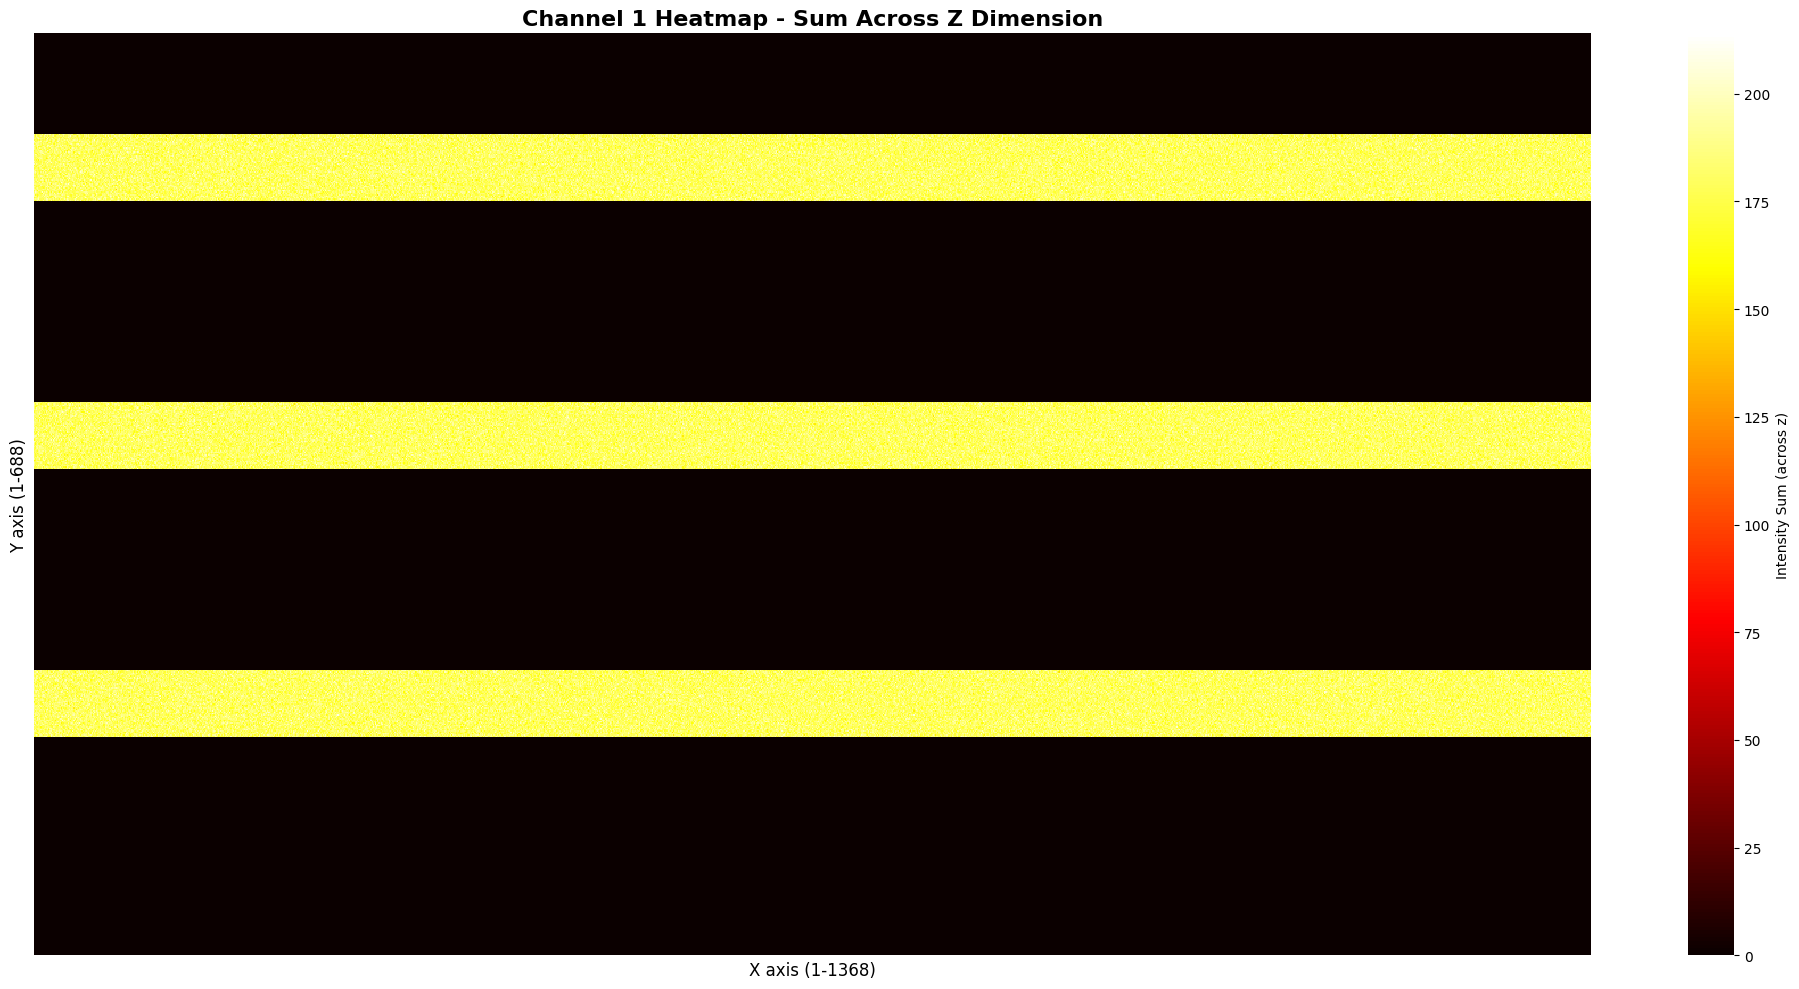

✓ Average heatmap saved to: channel1_heatmap_avg.png


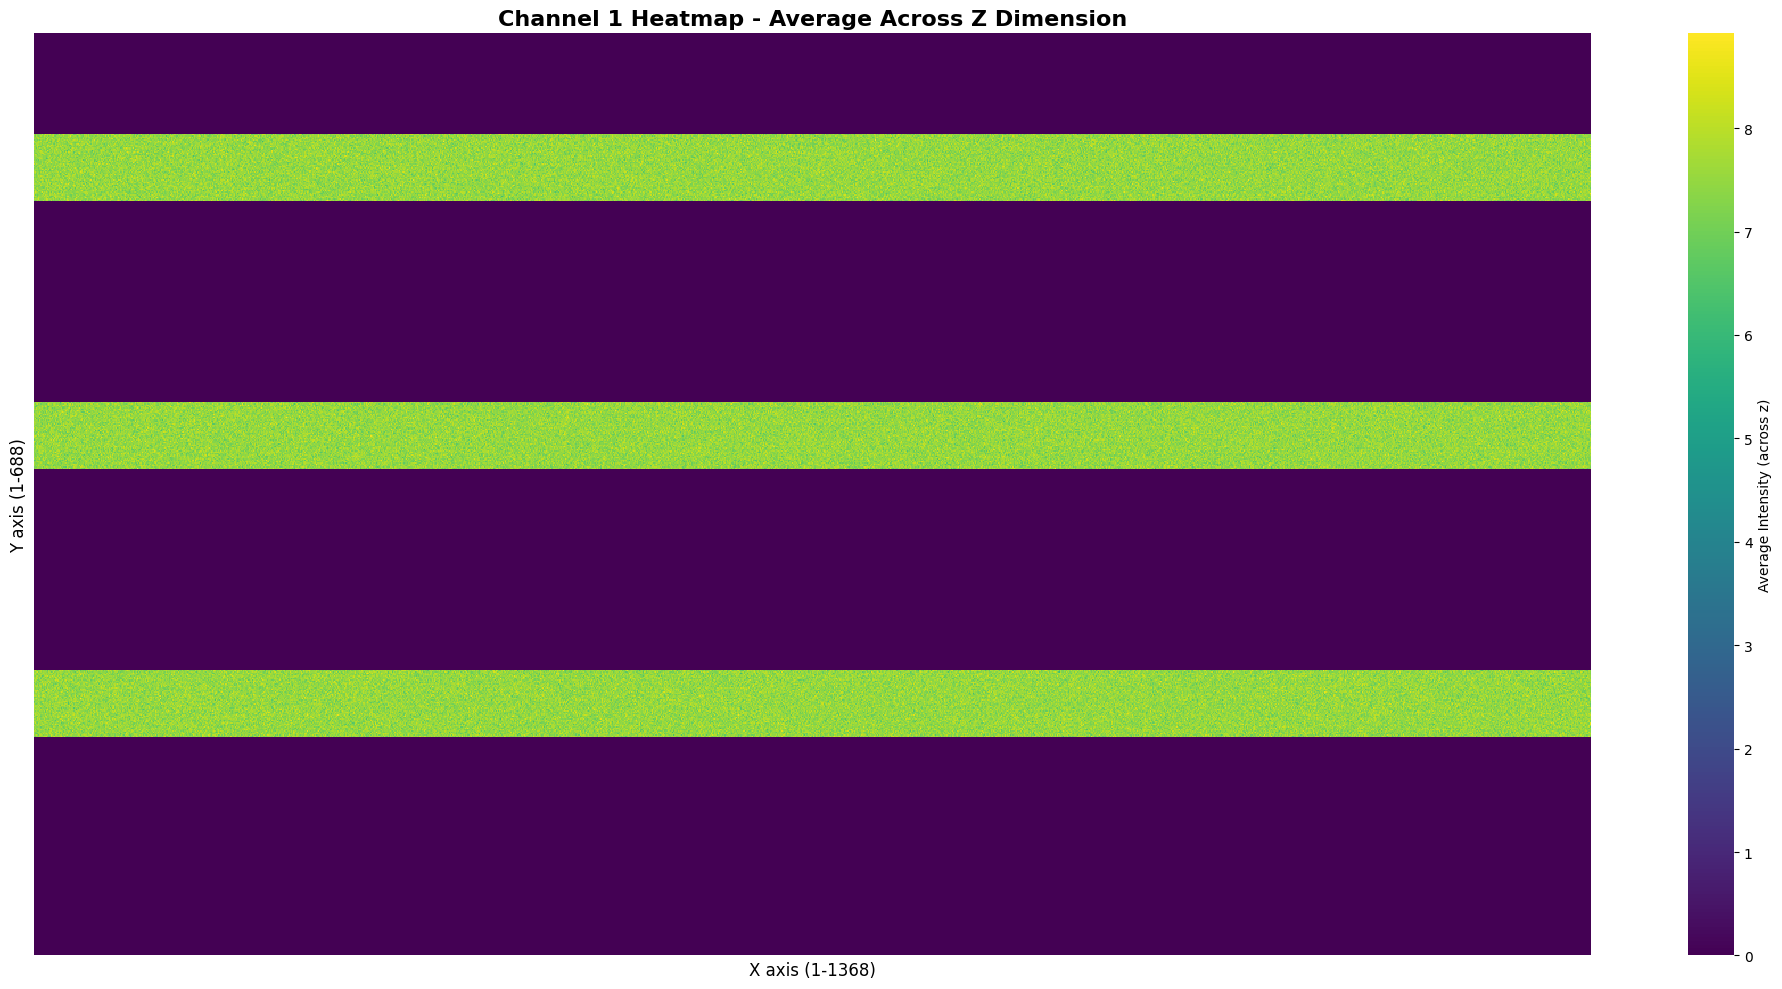

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
data = np.load('channel1.npy')
print(f"Loaded data shape: {data.shape}")

# Extract channel 1 (index 0)
channel1_data = data[0]  # Shape: (z, y, x)

# Create 2D projection by summing across z dimension
# This gives us a (y, x) heatmap showing total intensity across all z layers
heatmap_2d = np.sum(channel1_data, axis=0)  # Sum across z dimension

print(f"Heatmap shape: {heatmap_2d.shape}")
print(f"Heatmap value range: [{heatmap_2d.min()}, {heatmap_2d.max()}]")

# Create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d, 
            cmap='hot', 
            cbar_kws={'label': 'Intensity Sum (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 1 Heatmap - Sum Across Z Dimension', fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel1_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved to: channel1_heatmap.png")
plt.show()

# Also create a visualization showing average across z
heatmap_2d_avg = np.mean(channel1_data, axis=0)  # Average across z dimension

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d_avg, 
            cmap='viridis', 
            cbar_kws={'label': 'Average Intensity (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 1 Heatmap - Average Across Z Dimension', fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel1_heatmap_avg.png', dpi=300, bbox_inches='tight')
print("✓ Average heatmap saved to: channel1_heatmap_avg.png")
plt.show()


## Visualize Channel 12 Heatmap

Create a heatmap visualization of channel12 (combined channel 1 + channel 2).


Loaded channel12 data shape: (24, 688, 1368)
Heatmap shape: (688, 1368)
Heatmap value range: [0, 406]

✓ Heatmap saved to: channel12_heatmap.png


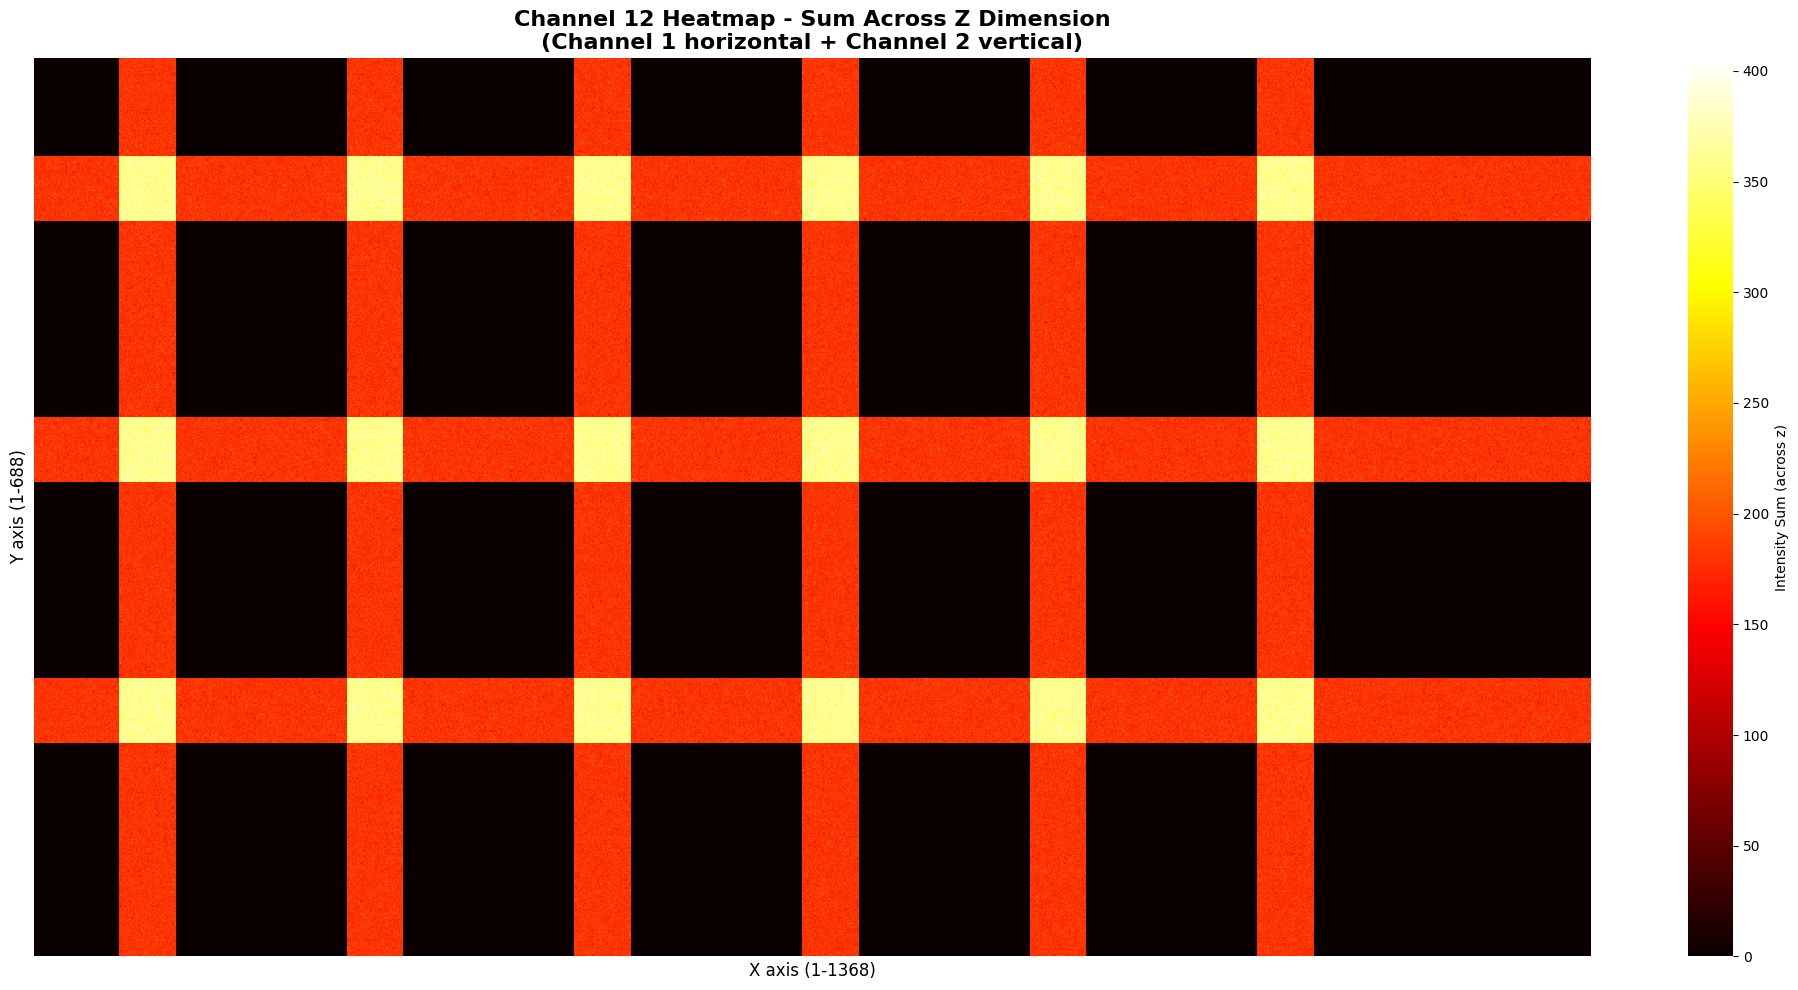

✓ Average heatmap saved to: channel12_heatmap_avg.png


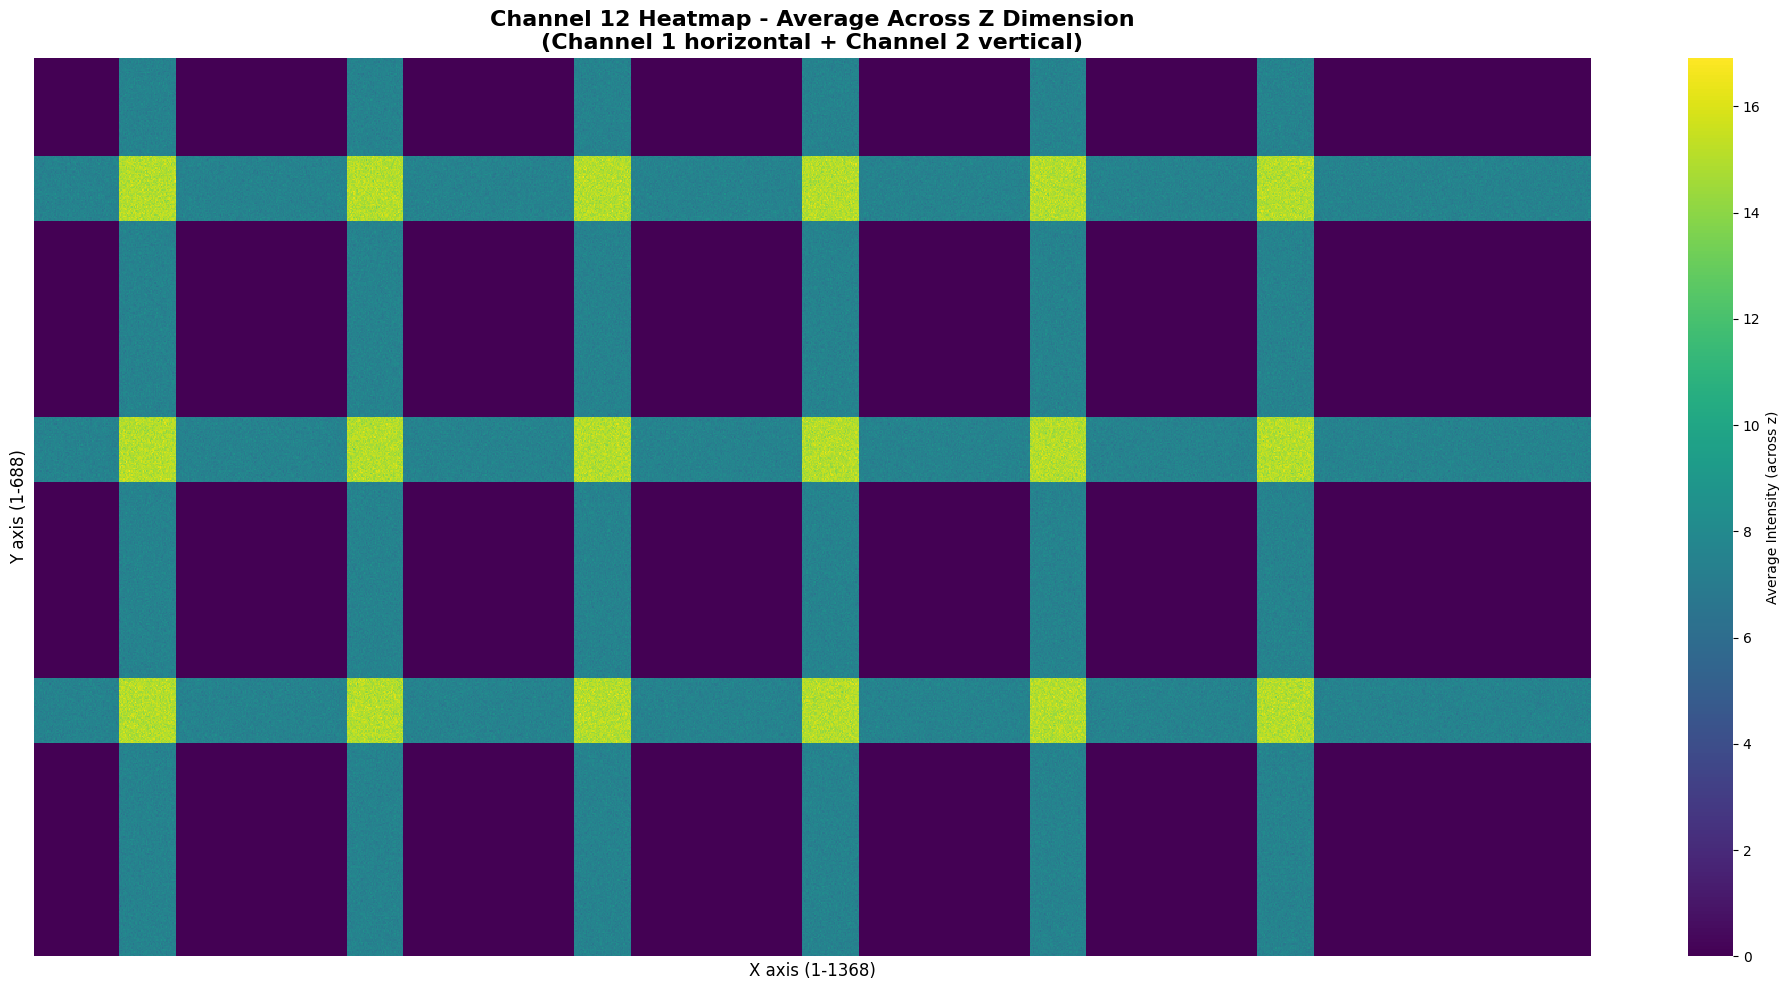


Note: Intersection points show higher intensity values
  (where horizontal strips from Channel 1 meet vertical strips from Channel 2)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load channel12 data
channel12_data = np.load('channel12.npy')
print(f"Loaded channel12 data shape: {channel12_data.shape}")

# Create 2D projection by summing across z dimension
# This gives us a (y, x) heatmap showing total intensity across all z layers
heatmap_2d = np.sum(channel12_data, axis=0)  # Sum across z dimension

print(f"Heatmap shape: {heatmap_2d.shape}")
print(f"Heatmap value range: [{heatmap_2d.min()}, {heatmap_2d.max()}]")

# Create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d, 
            cmap='hot', 
            cbar_kws={'label': 'Intensity Sum (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 12 Heatmap - Sum Across Z Dimension\n(Channel 1 horizontal + Channel 2 vertical)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel12_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved to: channel12_heatmap.png")
plt.show()

# Also create a visualization showing average across z
heatmap_2d_avg = np.mean(channel12_data, axis=0)  # Average across z dimension

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d_avg, 
            cmap='viridis', 
            cbar_kws={'label': 'Average Intensity (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 12 Heatmap - Average Across Z Dimension\n(Channel 1 horizontal + Channel 2 vertical)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel12_heatmap_avg.png', dpi=300, bbox_inches='tight')
print("✓ Average heatmap saved to: channel12_heatmap_avg.png")
plt.show()

# Show intersection points (where both channels overlap)
print(f"\nNote: Intersection points show higher intensity values")
print(f"  (where horizontal strips from Channel 1 meet vertical strips from Channel 2)")


## Add Channel 3 with Diagonal Strips (Slope +1)

Create channel 3 with diagonal strips (y = x + N) and combine with channel12 to create channel123.


In [14]:
import numpy as np

# Load channel12 data
channel12_data = np.load('channel12.npy')
print(f"Loaded channel12 data shape: {channel12_data.shape}")

# Get dimensions
z_dim, y_dim, x_dim = channel12_data.shape

# Initialize channel 3 (diagonal strips with slope +1)
channel3 = np.zeros((z_dim, y_dim, x_dim), dtype=np.int8)

# Channel 3 parameters: diagonal strips y = x + N
strip_width = 50
N_values = [0, 300, -300]  # y = x + N for these N values
intensity_min = 5
intensity_max = 10

print("Creating Channel 3 (diagonal strips with slope +1):")
print(f"  Strip width: {strip_width}")
print(f"  Lines: y = x + N, where N = {N_values}")
print(f"  Intensity range: {intensity_min} to {intensity_max}")

# For diagonal strips, we check perpendicular distance to the line y = x + N
# Distance from point (x, y) to line y = x + N is |y - x - N| / sqrt(2)
# We want points where this distance <= strip_width / 2
distance_threshold = (strip_width / 2) * np.sqrt(2)

# Create diagonal strips for channel 3
for N in N_values:
    print(f"\n  Processing diagonal strip: y = x + {N}")
    strip_count = 0
    
    for z in range(z_dim):
        for y in range(y_dim):
            for x in range(x_dim):
                # Calculate perpendicular distance to line y = x + N
                distance = abs(y - x - N) / np.sqrt(2)
                
                # If point is within strip width, assign intensity
                if distance <= distance_threshold:
                    intensity_value = np.random.randint(intensity_min, intensity_max + 1)
                    channel3[z, y, x] = intensity_value
                    strip_count += 1
    
    print(f"    Added {strip_count} points to strip")

print(f"\n✓ Channel 3 created: {np.count_nonzero(channel3)} non-zero values")

# Combine channel12 + channel3 to create channel123
# Add values where they overlap
channel123 = channel12_data.astype(np.int16) + channel3.astype(np.int16)
channel123 = np.clip(channel123, 0, 255).astype(np.int8)

print(f"\n✓ Channel 123 created by adding Channel 12 + Channel 3")
print(f"  Where channels overlap, values are added together")
print(f"  Total non-zero values: {np.count_nonzero(channel123)}")
print(f"  Data range: [{channel123.min()}, {channel123.max()}]")
print(f"  Data shape: {channel123.shape} (z, y, x)")

# Save channel123
np.save('channel123.npy', channel123)
print(f"\n✓ Channel 123 saved to: channel123.npy")
print(f"  Shape: (z={z_dim}, y={y_dim}, x={x_dim})")
print(f"  Contains: Channel 1 (horizontal) + Channel 2 (vertical) + Channel 3 (diagonal)")


Loaded channel12 data shape: (24, 688, 1368)
Creating Channel 3 (diagonal strips with slope +1):
  Strip width: 50
  Lines: y = x + N, where N = [0, 300, -300]
  Intensity range: 5 to 10

  Processing diagonal strip: y = x + 0
    Added 1637112 points to strip

  Processing diagonal strip: y = x + 300
    Added 940512 points to strip

  Processing diagonal strip: y = x + -300
    Added 1667712 points to strip

✓ Channel 3 created: 4245336 non-zero values

✓ Channel 123 created by adding Channel 12 + Channel 3
  Where channels overlap, values are added together
  Total non-zero values: 11238336
  Data range: [0, 30]
  Data shape: (24, 688, 1368) (z, y, x)

✓ Channel 123 saved to: channel123.npy
  Shape: (z=24, y=688, x=1368)
  Contains: Channel 1 (horizontal) + Channel 2 (vertical) + Channel 3 (diagonal)


## Visualize Channel 123 Heatmap

Create a heatmap visualization of channel123 (combined channel 1 + channel 2 + channel 3).


Loaded channel123 data shape: (24, 688, 1368)
Heatmap shape: (688, 1368)
Heatmap value range: [0, 592]

✓ Heatmap saved to: channel123_heatmap.png


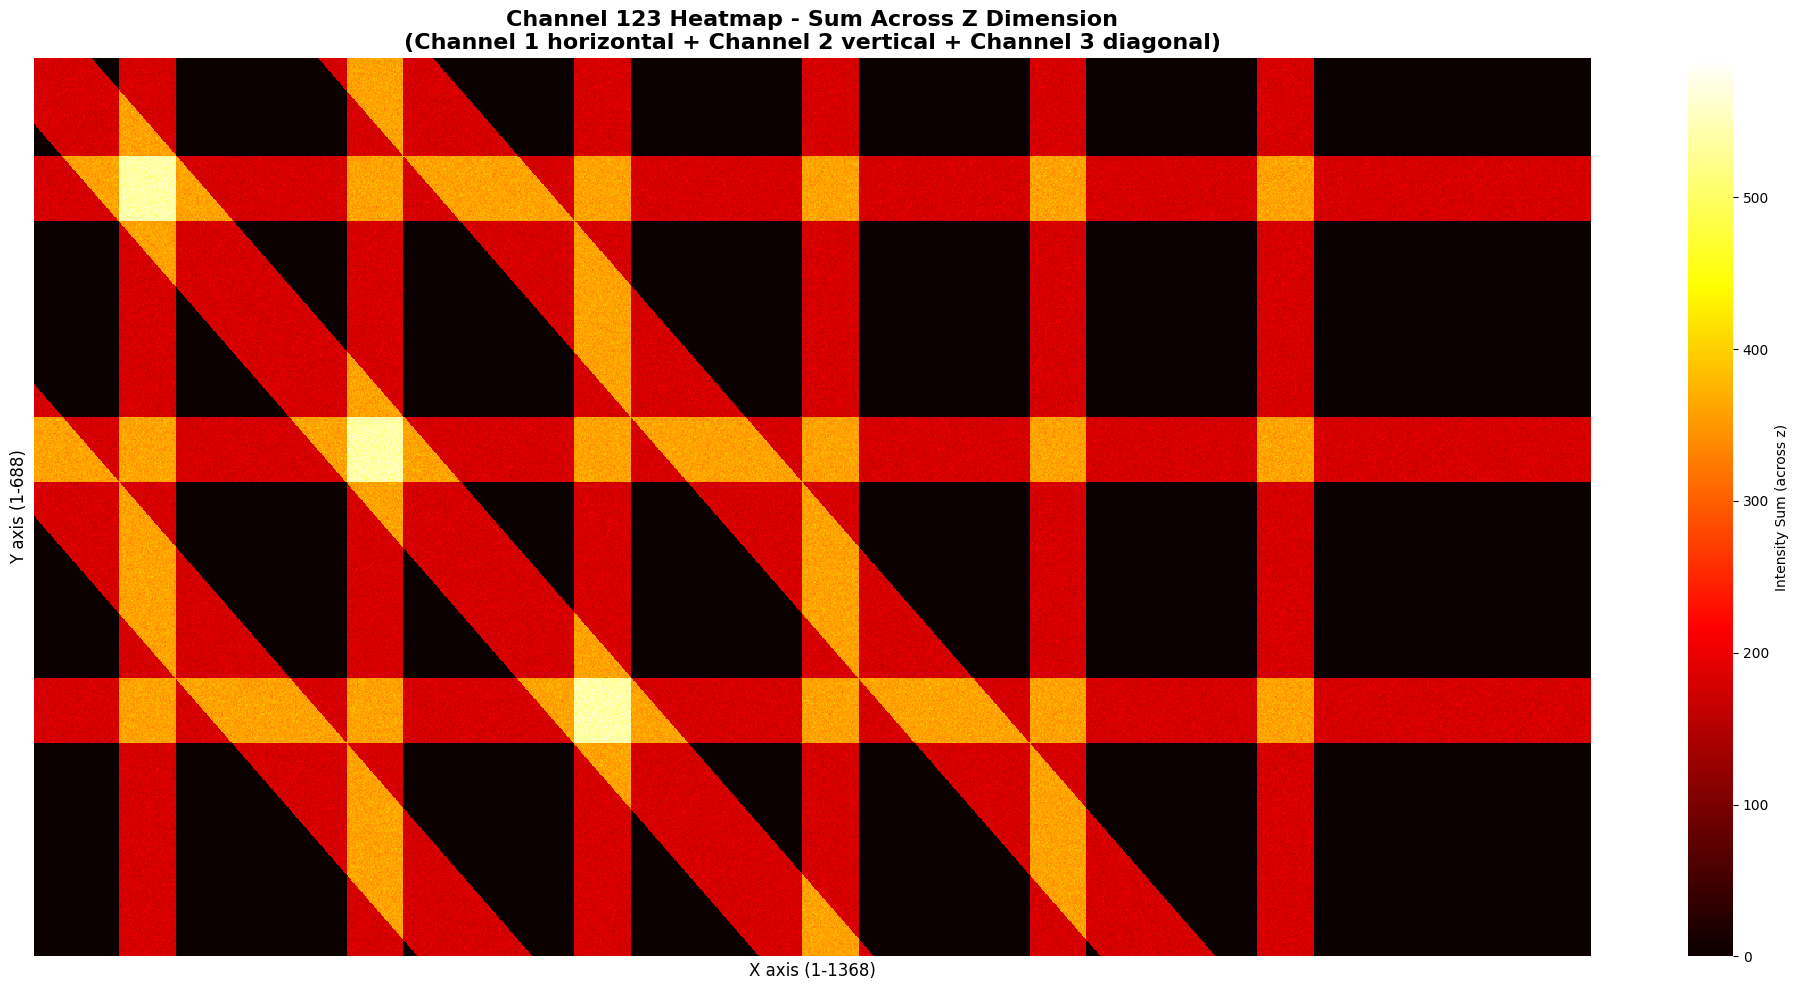

✓ Average heatmap saved to: channel123_heatmap_avg.png


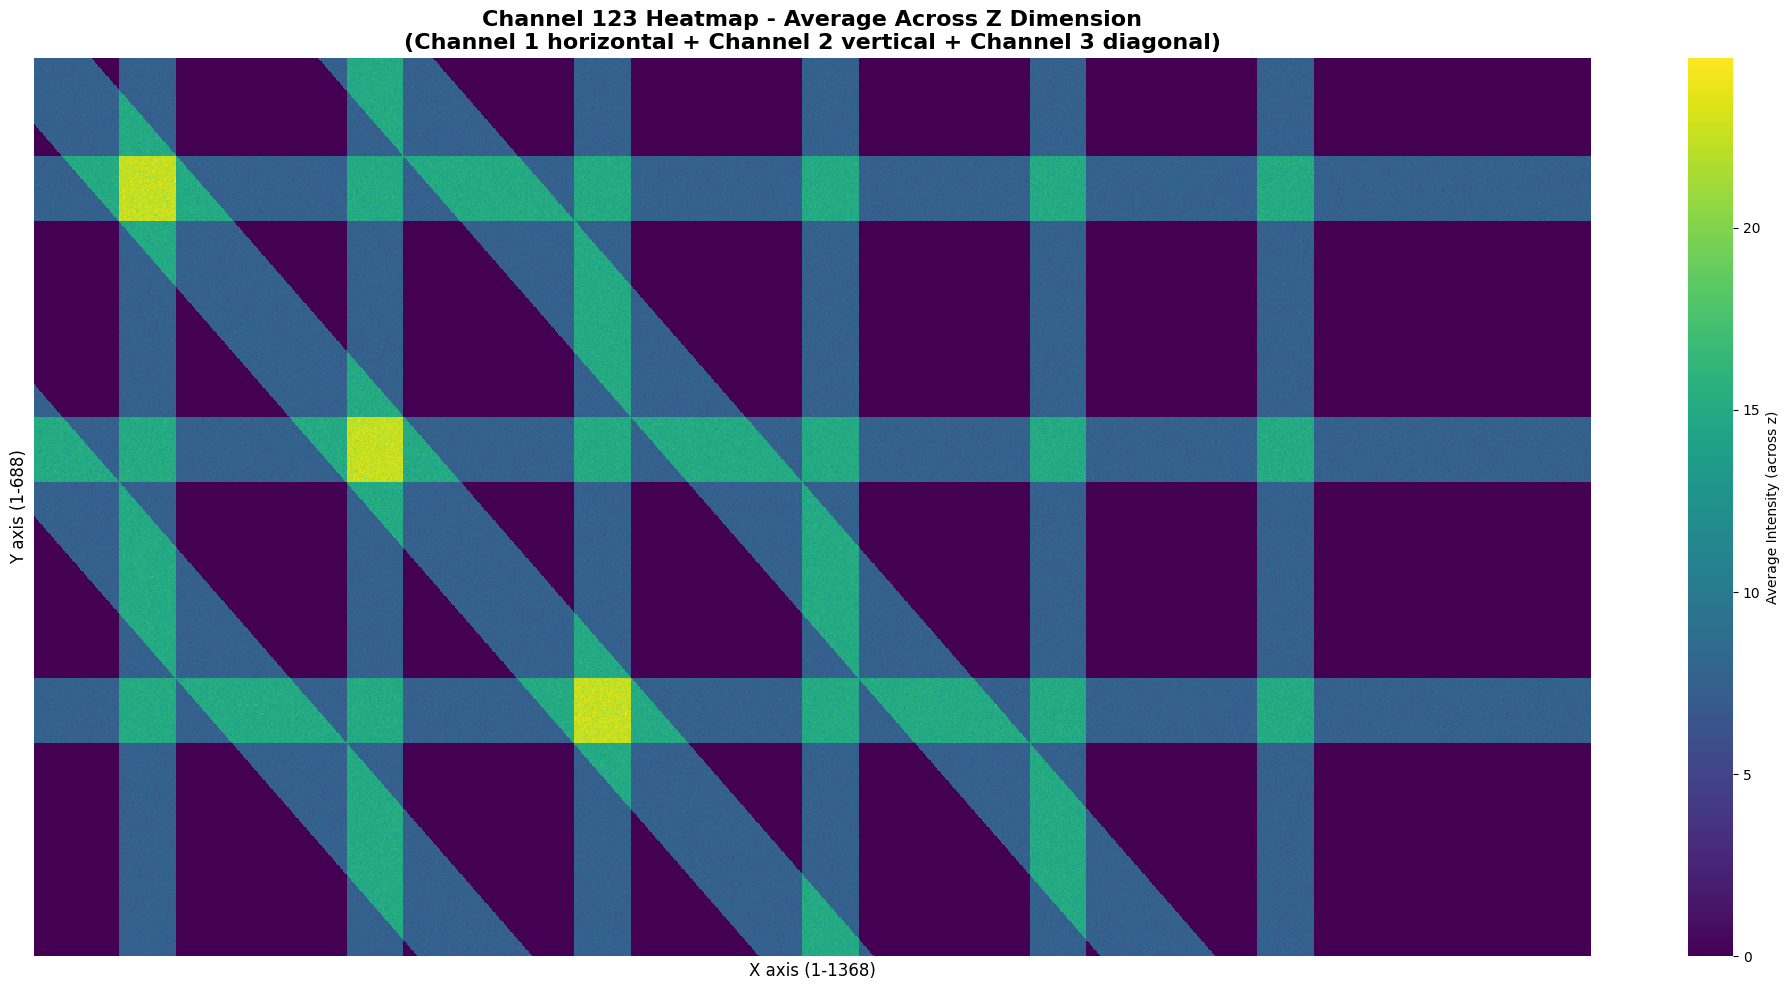


Note: Intersection points show higher intensity values
  - Horizontal strips (Channel 1) at y = 100, 300, 500
  - Vertical strips (Channel 2) at x = 100, 300, 500, 700, 900, 1100
  - Diagonal strips (Channel 3) with slope +1: y = x + 0, y = x + 300, y = x - 300
  - Where all three types intersect, values are added together (can reach up to 30)


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load channel123 data
channel123_data = np.load('channel123.npy')
print(f"Loaded channel123 data shape: {channel123_data.shape}")

# Create 2D projection by summing across z dimension
# This gives us a (y, x) heatmap showing total intensity across all z layers
heatmap_2d = np.sum(channel123_data, axis=0)  # Sum across z dimension

print(f"Heatmap shape: {heatmap_2d.shape}")
print(f"Heatmap value range: [{heatmap_2d.min()}, {heatmap_2d.max()}]")

# Create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d, 
            cmap='hot', 
            cbar_kws={'label': 'Intensity Sum (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 123 Heatmap - Sum Across Z Dimension\n(Channel 1 horizontal + Channel 2 vertical + Channel 3 diagonal)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel123_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved to: channel123_heatmap.png")
plt.show()

# Also create a visualization showing average across z
heatmap_2d_avg = np.mean(channel123_data, axis=0)  # Average across z dimension

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d_avg, 
            cmap='viridis', 
            cbar_kws={'label': 'Average Intensity (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 123 Heatmap - Average Across Z Dimension\n(Channel 1 horizontal + Channel 2 vertical + Channel 3 diagonal)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel123_heatmap_avg.png', dpi=300, bbox_inches='tight')
print("✓ Average heatmap saved to: channel123_heatmap_avg.png")
plt.show()

# Show intersection points information
print(f"\nNote: Intersection points show higher intensity values")
print(f"  - Horizontal strips (Channel 1) at y = 100, 300, 500")
print(f"  - Vertical strips (Channel 2) at x = 100, 300, 500, 700, 900, 1100")
print(f"  - Diagonal strips (Channel 3) with slope +1: y = x + 0, y = x + 300, y = x - 300")
print(f"  - Where all three types intersect, values are added together (can reach up to 30)")


## Add Channel 4 with Diagonal Strips (Slope -1)

Create channel 4 with diagonal strips (y = -x + N) and combine with channel123 to create channel1234.


In [ ]:
import numpy as np

# Load channel123 data
channel123_data = np.load('channel123.npy')
print(f"Loaded channel123 data shape: {channel123_data.shape}")

# Get dimensions
z_dim, y_dim, x_dim = channel123_data.shape

# Initialize channel 4 (diagonal strips with slope -1)
channel4 = np.zeros((z_dim, y_dim, x_dim), dtype=np.int8)

# Channel 4 parameters: diagonal strips y = -x + N
strip_width = 50
N_values = [0, 300, -300]  # y = -x + N for these N values
intensity_min = 5
intensity_max = 10

print("Creating Channel 4 (diagonal strips with slope -1):")
print(f"  Strip width: {strip_width}")
print(f"  Lines: y = -x + N, where N = {N_values}")
print(f"  Intensity range: {intensity_min} to {intensity_max}")

# For diagonal strips with slope -1, we check perpendicular distance to the line y = -x + N
# The line can be rewritten as x + y = N
# Distance from point (x, y) to line x + y = N is |x + y - N| / sqrt(2)
# We want points where this distance <= strip_width / 2
distance_threshold = (strip_width / 2) * np.sqrt(2)

# Create diagonal strips for channel 4
for N in N_values:
    print(f"\n  Processing diagonal strip: y = -x + {N}")
    strip_count = 0
    
    for z in range(z_dim):
        for y in range(y_dim):
            for x in range(x_dim):
                # Calculate perpendicular distance to line y = -x + N (or x + y = N)
                distance = abs(x + y - N) / np.sqrt(2)
                
                # If point is within strip width, assign intensity
                if distance <= distance_threshold:
                    intensity_value = np.random.randint(intensity_min, intensity_max + 1)
                    channel4[z, y, x] = intensity_value
                    strip_count += 1
    
    print(f"    Added {strip_count} points to strip")

print(f"\n✓ Channel 4 created: {np.count_nonzero(channel4)} non-zero values")

# Combine channel123 + channel4 to create channel1234
# Add values where they overlap
channel1234 = channel123_data.astype(np.int16) + channel4.astype(np.int16)
channel1234 = np.clip(channel1234, 0, 255).astype(np.int8)

print(f"\n✓ Channel 1234 created by adding Channel 123 + Channel 4")
print(f"  Where channels overlap, values are added together")
print(f"  Total non-zero values: {np.count_nonzero(channel1234)}")
print(f"  Data range: [{channel1234.min()}, {channel1234.max()}]")
print(f"  Data shape: {channel1234.shape} (z, y, x)")

# Save channel1234
np.save('channel1234.npy', channel1234)
print(f"\n✓ Channel 1234 saved to: channel1234.npy")
print(f"  Shape: (z={z_dim}, y={y_dim}, x={x_dim})")
print(f"  Contains: Channel 1 (horizontal) + Channel 2 (vertical) + Channel 3 (diagonal +1) + Channel 4 (diagonal -1)")


Loaded channel123 data shape: (24, 688, 1368)
Creating Channel 4 (diagonal strips with slope -1):
  Strip width: 50
  Lines: y = -x + N, where N = [0, 300, -300]
  Intensity range: 5 to 10

  Processing diagonal strip: y = -x + 0
    Added 31824 points to strip

  Processing diagonal strip: y = -x + 300


## Visualize Channel 1234 Heatmap

Create a heatmap visualization of channel1234 (all four channels combined).
 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load channel1234 data
channel1234_data = np.load('channel1234.npy')
print(f"Loaded channel1234 data shape: {channel1234_data.shape}")

# Create 2D projection by summing across z dimension
# This gives us a (y, x) heatmap showing total intensity across all z layers
heatmap_2d = np.sum(channel1234_data, axis=0)  # Sum across z dimension

print(f"Heatmap shape: {heatmap_2d.shape}")
print(f"Heatmap value range: [{heatmap_2d.min()}, {heatmap_2d.max()}]")

# Create the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d, 
            cmap='hot', 
            cbar_kws={'label': 'Intensity Sum (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 1234 Heatmap - Sum Across Z Dimension\n(All channels: horizontal + vertical + diagonal +1 + diagonal -1)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel1234_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved to: channel1234_heatmap.png")
plt.show()

# Also create a visualization showing average across z
heatmap_2d_avg = np.mean(channel1234_data, axis=0)  # Average across z dimension

plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_2d_avg, 
            cmap='viridis', 
            cbar_kws={'label': 'Average Intensity (across z)'},
            xticklabels=False,
            yticklabels=False)
plt.title('Channel 1234 Heatmap - Average Across Z Dimension\n(All channels: horizontal + vertical + diagonal +1 + diagonal -1)', 
          fontsize=16, fontweight='bold')
plt.xlabel('X axis (1-1368)', fontsize=12)
plt.ylabel('Y axis (1-688)', fontsize=12)
plt.tight_layout()
plt.savefig('channel1234_heatmap_avg.png', dpi=300, bbox_inches='tight')
print("✓ Average heatmap saved to: channel1234_heatmap_avg.png")
plt.show()

# Show intersection points information
print(f"\nNote: Intersection points show higher intensity values")
print(f"  - Horizontal strips (Channel 1) at y = 100, 300, 500")
print(f"  - Vertical strips (Channel 2) at x = 100, 300, 500, 700, 900, 1100")
print(f"  - Diagonal strips +1 (Channel 3): y = x + 0, y = x + 300, y = x - 300")
print(f"  - Diagonal strips -1 (Channel 4): y = -x + 0, y = -x + 300, y = -x - 300")
print(f"  - Where all four types intersect, values are added together (can reach up to 40)")
